### Intuition 
We know its best to initialize weights with random values  
But _What should be the range?_ 

Consider this:
- Let $n$ = number of inputs coming to a node in neural network

    - Weights initialized with large values and $n$ is also large (high number of inputs to the node): 
        - Then, number of inputs is large --> $W^Tx + b$ summation is large --> acitvation is large (for relu) and saturated (for tanh at -1 or 1, for sigmoid at 0 or 1) and hence problems 
    
    - Weights initialized with small values and $n$ is also small (less number of inputs to the node):
        - Then, number of inputs is small --> summation is small --> activation is small --> derivatives are small --> Vanishing gradient problem 




So the solution is: 
- Let range of weights be inversely proportional to $n$ (number of inputs to the node)  
i.e multiply the weights with set of different values which have 
$$
\text{variance} = \frac{1}{n}
$$


__This is the intuition only actual formulae in different techniques differ a lil__

Note: There are two types of random initialization: `Normal` and `Uniform`
- Normal: 
Weights belong to normal distribution
- Uniform: 
Weights belong to uniform distribution

### __Initialization Techniques__
1. Xavier/Glorat Initialization (Good for tanh/sigmoid)
    - Normal
    - Uniform

2. He Initialization (Good for Relu)
    - Normal
    - Uniform

### 1. Xavier initialization or (Glorat initialization)

1. Uniform Xavier initialization
$$
x = \sqrt{\frac{6}{\text{fan-in} + \text{fan-out}}}
$$

Here, For each weight in network we draw a random value w from a uniform distribution in the range [-x, x].

- fan_in = number of incoming connections to a neuron
- fan_out = number of outgoing connections from that neuron


2. Normal Xavier initialization
$$
\sigma = \sqrt{\frac{2}{\text{fan-in} + \text{fan-out}}}
$$

Here, For each weight in network we draw a random value w from a Normal distribution with mean=0, standard deviation $\sigma$

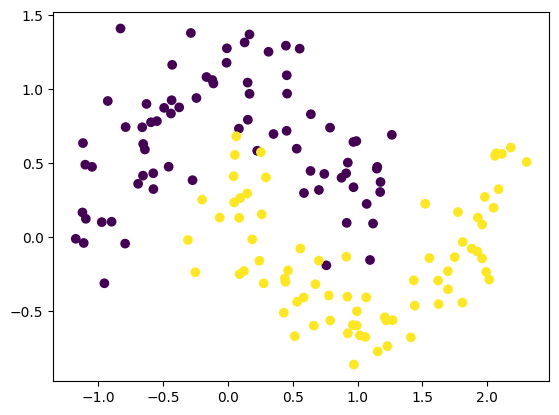

In [11]:
from keras import Sequential
from keras.layers import Dense, Input
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

X,y = make_moons(150, noise=0.2)
plt.scatter(X[:,0],X[:,1],c=y)

In [12]:
model1 = Sequential()
model1.add(Input((X.shape[1],)))
model1.add(Dense(16, activation='tanh'))
model1.add(Dense(16, activation='tanh'))
model1.add(Dense(1, activation='sigmoid'))

#get weights
weights1 = model1.get_weights()

#Initialize weights using normal xavier technique (set bias to zero for ease rn)
weights1[0] = np.random.randn(weights1[0].shape[0],weights1[0].shape[1]) * np.sqrt(1/2)
weights1[1] = np.zeros(weights1[1].shape[0])
weights1[2] = np.random.randn(weights1[2].shape[0],weights1[2].shape[1]) * np.sqrt(1/16)
weights1[3] = np.zeros(weights1[3].shape[0])
weights1[4] = np.random.randn(weights1[4].shape[0],weights1[4].shape[1]) * np.sqrt(1/16)
weights1[5] = np.zeros(weights1[5].shape[0])

#set weights
model1.set_weights(weights1)

model1.compile(optimizer='adam',loss='binary_crossentropy', metrics=['Accuracy'])
history1 = model1.fit(X,y,epochs=200,verbose=1)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - Accuracy: 0.2333 - loss: 0.8463  
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.2867 - loss: 0.7929 
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.3400 - loss: 0.7437 
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.4200 - loss: 0.6999 
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - Accuracy: 0.6600 - loss: 0.6602
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Accuracy: 0.7800 - loss: 0.6234 
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.7800 - loss: 0.5930 
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.7800 - loss: 0.5639 
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.7867 - loss: 0.5396 
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.7867 - loss: 0.5169 
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.7867 - loss: 0.4981 
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.7867 - lo

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 6s 656us/step


<Axes: >

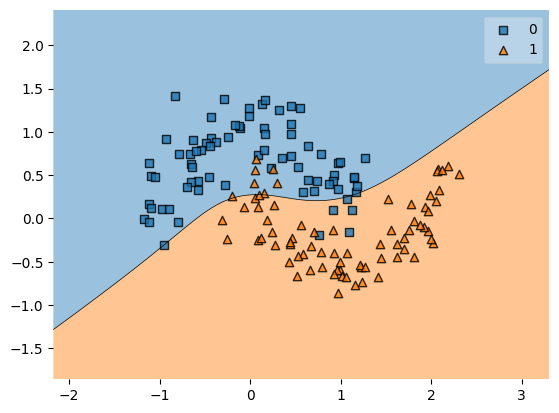

In [13]:
plot_decision_regions(X,y, model1)

### 2. He initialization

1. Uniform He initialization
$$
x = \sqrt{\frac{6}{\text{fan-in}}}
$$

Here, For each weight in network we draw a random value w from a uniform distribution in the range [-x, x].

- fan_in = number of incoming connections to a neuron

2. Normal He initialization
$$
\sigma = \sqrt{\frac{2}{\text{fan-in}}}
$$

Here, For each weight in network we draw a random value w from a Normal distribution with mean=0, standard deviation $\sigma$

In [ ]:
## Code implementation

## Default kernel = glorot_uniform
model2 = Sequential()
model2.add(Input((X.shape[1],)))
model2.add(Dense(16, activation='relu', kernel_initializer='he_normal'))
model2.add(Dense(16, activation='relu', kernel_initializer='he_normal'))
model2.add(Dense(1, activation='sigmoid'))


model2.compile(optimizer='adam',loss='binary_crossentropy', metrics=['Accuracy'])
history2 = model2.fit(X,y,epochs=200,verbose=1)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - Accuracy: 0.4933 - loss: 0.5976
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5133 - loss: 0.5824 
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5667 - loss: 0.5674 
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.5933 - loss: 0.5543 
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.6600 - loss: 0.5426 
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.7200 - loss: 0.5318 
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Accuracy: 0.7200 - loss: 0.5202 
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.7200 - loss: 0.5111 
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.7467 - loss: 0.5015 
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.7667 - loss: 0.4923 
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.7800 - loss: 0.4821 
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.7933 - los

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 6s 612us/step


<Axes: >

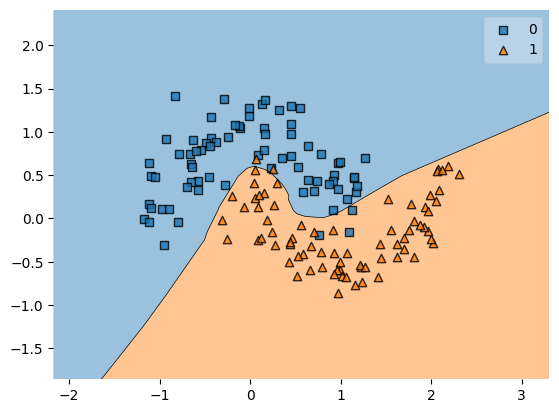

In [15]:
plot_decision_regions(X,y,model2)

Note: 
||glorot|he|
|--|-----|----|
|variance in weights|$\sqrt{\frac{1}{fan-in}}$|$\sqrt{\frac{2}{fan-in}}$|

- Default initializer = Xavier